# 01 — Data preparation

**Goal.** Load the four source files, establish the experimental benchmark, and build the two
observational samples that the rest of the project tries to correct.

| | |
|---|---|
| **Reads** | `data/raw/lalonde/*.txt` |
| **Writes** | `outputs/data/01_sample_cps.csv`, `01_sample_psid.csv`, `01_benchmark.json` |

**Questions this notebook answers**

1. What is in each of the four files?
2. What is the true effect, measured from the randomized experiment?
3. What does a naive comparison give once the randomized controls are thrown away?
4. How far apart are the two groups before any adjustment?

In [1]:
import sys
sys.path.insert(0, "..")

import json
import warnings

# this environment ships slightly old numexpr/bottleneck; the warnings are noise
warnings.filterwarnings("ignore", message=".*numexpr.*")
warnings.filterwarnings("ignore", message=".*bottleneck.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from src import psm, data, figures

pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:,.2f}".format)

%matplotlib inline

## 1. The four files

All four have the same ten columns, no header, whitespace separated. `re74`, `re75` and `re78`
are real (inflation-adjusted) earnings in those years, so the first two are pre-treatment and
`re78` is the outcome.

Two of the files are the arms of a randomized experiment. The other two are ordinary survey
respondents who have nothing to do with the program.

In [2]:
raw = data.load_lalonde()

for name, df in raw.items():
    print(f"{name:12s} {len(df):>6,} rows")

print()
raw["nsw_treated"].head(3)

nsw_treated     185 rows
nsw_control     260 rows
cps          15,992 rows
psid          2,490 rows



,treat,age,educ,black,hisp,married,nodegree,re74,re75,re78
0,1.00,37.00,11.00,1.00,0.00,1.00,1.00,0.00,0.00,"9,930.05"
1,1.00,22.00,9.00,0.00,1.00,0.00,1.00,0.00,0.00,"3,595.89"
2,1.00,30.00,12.00,1.00,0.00,0.00,0.00,0.00,0.00,"24,909.45"


## 2. The experimental benchmark

The National Supported Work program had more applicants than places, so admission was decided
by lottery. That single fact is what makes this dataset valuable: with random assignment, the
two arms are comparable on everything, measured or not, so a plain difference in mean `re78`
is already an unbiased estimate of the effect. No modelling required.

This number is the answer key. Everything the rest of the project does is an attempt to
recover it without being allowed to look at it.

In [3]:
exp = data.build_experimental()
y_t = exp.loc[exp.treat == 1, "re78"]
y_c = exp.loc[exp.treat == 0, "re78"]

benchmark = y_t.mean() - y_c.mean()
test = stats.ttest_ind(y_t, y_c, equal_var=False)   # Welch: arms have unequal variance
ci_lo, ci_hi = test.confidence_interval(0.95)

print(f"treated mean 1978 earnings : ${y_t.mean():>9,.0f}  (n={len(y_t)})")
print(f"control mean 1978 earnings : ${y_c.mean():>9,.0f}  (n={len(y_c)})")
print(f"\nBENCHMARK ATT              : ${benchmark:>9,.0f}")
print(f"95% CI                     : [${ci_lo:,.0f}, ${ci_hi:,.0f}]   width ${ci_hi-ci_lo:,.0f}")
print(f"p-value                    : {test.pvalue:.4f}")

treated mean 1978 earnings : $    6,349  (n=185)
control mean 1978 earnings : $    4,555  (n=260)

BENCHMARK ATT              : $    1,794
95% CI                     : [$474, $3,115]   width $2,641
p-value                    : 0.0079


### What randomization bought us

Compare the two randomized arms on their covariates. They are nearly identical: less than a
year apart in age, a tenth of a year in education, one percentage point in race. Nobody
adjusted anything to make that happen; the lottery did it.

Hold this table in mind. In the next section the control group gets replaced, and the same
comparison falls apart.

In [4]:
covs = data.covariate_spec("with_earnings")
arms = exp.groupby("treat")[covs].mean().T
arms.columns = ["NSW control (n=260)", "NSW treated (n=185)"]
arms["difference"] = arms.iloc[:, 1] - arms.iloc[:, 0]
arms

,NSW control (n=260),NSW treated (n=185),difference
age,25.05,25.82,0.76
educ,10.09,10.35,0.26
black,0.83,0.84,0.02
hisp,0.11,0.06,-0.05
married,0.15,0.19,0.04
nodegree,0.83,0.71,-0.13
re74,"2,107.03","2,095.57",-11.45
re75,"1,266.91","1,532.06",265.15
u74,0.75,0.71,-0.04
u75,0.68,0.60,-0.08


## 3. Throwing the randomized controls away

Now the research design of LaLonde (1986). Discard the 260 randomized controls and pretend we
only ever had the 185 participants. For a comparison group, reach for a national survey and
take ordinary people who were never in the program.

Two survey pools are used, and they are kept strictly separate. They are two independent
replications of the same test at different difficulty levels, and merging them would let the
matching step draw from whichever pool is easier, hiding the very problem worth exposing.

In [5]:
samples = {pool: data.build_observational(pool) for pool in ["cps", "psid"]}

rows = []
for pool, df in samples.items():
    t, c = df.loc[df.treat == 1, "re78"], df.loc[df.treat == 0, "re78"]
    rows.append({
        "pool": pool.upper(),
        "n_treated": int((df.treat == 1).sum()),
        "n_control": int((df.treat == 0).sum()),
        "treated_share": (df.treat == 1).mean(),
        "mean_re78_treated": t.mean(),
        "mean_re78_control": c.mean(),
        "naive_difference": t.mean() - c.mean(),
    })

naive = pd.DataFrame(rows).set_index("pool")
naive

,n_treated,n_control,treated_share,mean_re78_treated,mean_re78_control,naive_difference
pool,,,,,,
CPS,185,15992,0.01,"6,349.14","14,846.66","-8,497.52"
PSID,185,2490,0.07,"6,349.14","21,553.92","-15,204.78"


The naive comparison is not merely biased. It has the **wrong sign** and is off by more than
ten thousand dollars. Taken at face value it says job training destroyed participants' earnings.

It also shows why the two pools are not interchangeable: PSID respondents earn more than CPS
respondents, so the same treated group looks even worse against them. And treated units are a
tiny minority of each sample, roughly 1% under CPS and 7% under PSID, which is what makes the
propensity scores in the next notebook pile up near zero.

## 4. How far apart are the groups?

The standardized mean difference expresses each covariate's gap in pooled standard deviations,
so variables measured in dollars and variables measured in years can be read on one axis. The
conventional threshold for "balanced" is 0.1.

Almost nothing here is close to 0.1. Race is off by more than two standard deviations under
CPS, pre-treatment earnings by more than one and a half, and marital status by nearly two
under PSID. The one exception is the Hispanic indicator, which happens to be similar in all
three groups and therefore carries no information about who ended up treated.

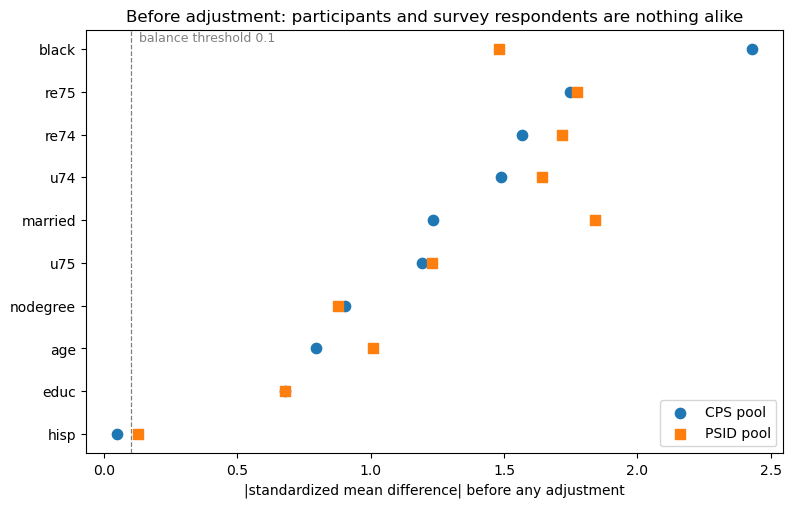

,CPS,PSID
black,2.43,1.48
re75,1.75,1.77
re74,1.57,1.72
u74,1.49,1.64
married,1.23,1.84
u75,1.19,1.23
nodegree,0.90,0.88
age,0.80,1.01
educ,0.68,0.68
hisp,0.05,0.13


In [6]:
gap = pd.DataFrame({
    pool.upper(): psm.smd(df[covs], df["treat"].values)
    for pool, df in samples.items()
})

order = gap["CPS"].abs().sort_values().index
fig, ax = plt.subplots(figsize=(9, 0.4 * len(order) + 1.5))
for col, marker in zip(gap.columns, ["o", "s"]):
    ax.scatter(gap.loc[order, col].abs(), order, marker=marker, s=55, label=f"{col} pool")
ax.axvline(0.1, ls="--", lw=0.9, color="grey")
ax.text(0.13, len(order) - 0.6, "balance threshold 0.1", color="grey", fontsize=9, va="top")
ax.set_xlabel("|standardized mean difference| before any adjustment")
ax.set_title("Before adjustment: participants and survey respondents are nothing alike")
ax.legend()

figures.save_fig(fig, "covariate_gap", close=False)
plt.show()

gap.abs().round(2).sort_values("CPS", ascending=False)

## 5. Save

Each notebook hands its work to the next one through files rather than memory, so any stage can
be re-run on its own and a reader can inspect the intermediate products on GitHub without
executing anything.

The benchmark goes out as JSON so notebook 04 can score its estimates against it without
reloading the experimental arms.

In [7]:
for pool, df in samples.items():
    path = data.save_stage(df, f"01_sample_{pool}")
    print(f"{path.name:24s} {df.shape[0]:>6,} rows x {df.shape[1]} cols")

bench = {
    "estimand": "ATT",
    "outcome": "re78",
    "estimate": float(benchmark),
    "ci_lo": float(ci_lo),
    "ci_hi": float(ci_hi),
    "p_value": float(test.pvalue),
    "n_treated": int(len(y_t)),
    "n_control": int(len(y_c)),
    "source": "NSW randomized experiment (Dehejia-Wahba re74 subsample)",
}
bench_path = data.OUT_DIR / "01_benchmark.json"
bench_path.write_text(json.dumps(bench, indent=2))
print(f"\n{bench_path.name}: ${bench['estimate']:,.0f}  [{bench['ci_lo']:,.0f}, {bench['ci_hi']:,.0f}]")

01_sample_cps.csv        16,177 rows x 20 cols
01_sample_psid.csv        2,675 rows x 20 cols

01_benchmark.json: $1,794  [474, 3,115]
